In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from Libraries.PolynomialRegression import AutoPolynomialRegression

1. Chọn cách nạp dữ liệu

In [2]:
way = 1

if way == 1:
    print("Chọn Data trên máy tính")
    df = pd.read_csv("Data/CSV/house_prices.csv")
else:
    print("Clone Data từ Sklearn")
    data = fetch_california_housing(as_frame=True)
    df = data.frame

print("Dữ liệu đã nạp:", df.shape)

Chọn Data trên máy tính
Dữ liệu đã nạp: (1460, 81)


2. Tạo đối tượng model với cấu hình

In [3]:
model = AutoPolynomialRegression(
    df,
    max_degree=4,        # bậc đa thức tối đa để thử
    cv_splits=5,         # số fold cho cross-validation
    test_size=0.2,       # 80/20
    random_state=42,
    choose_by="best",    # hoặc "1se"
    max_scatter_plots=9,

    # --- tham số bổ sung ---
    min_feature=5,       # số feature tối thiểu giữ lại
    min_degree=2,        # bậc tối thiểu
    cpu_cores=6,         # số nhân CPU muốn dùng
    ram_gb=12,           # dung lượng RAM vật lý
    safety_ratio=0.5,    # chỉ dùng 50% RAM để an toàn
)

3. Chạy pipeline theo từng bước

In [4]:
# Báo cáo tổng quan dữ liệu
model.report_overview()


=== Tổng quan dữ liệu ===
Số dòng: 1460, Số cột: 35

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Id             1460 non-null   int64
 1   MSSubClass     1460 non-null   int64
 2   LotArea        1460 non-null   int64
 3   OverallQual    1460 non-null   int64
 4   OverallCond    1460 non-null   int64
 5   YearBuilt      1460 non-null   int64
 6   YearRemodAdd   1460 non-null   int64
 7   BsmtFinSF1     1460 non-null   int64
 8   BsmtFinSF2     1460 non-null   int64
 9   BsmtUnfSF      1460 non-null   int64
 10  TotalBsmtSF    1460 non-null   int64
 11  1stFlrSF       1460 non-null   int64
 12  2ndFlrSF       1460 non-null   int64
 13  LowQualFinSF   1460 non-null   int64
 14  GrLivArea      1460 non-null   int64
 15  BsmtFullBath   1460 non-null   int64
 16  BsmtHalfBath   1460 non-null   int64
 17  FullBath       1460 non

In [5]:
# Chia train/test
model.read_and_split()

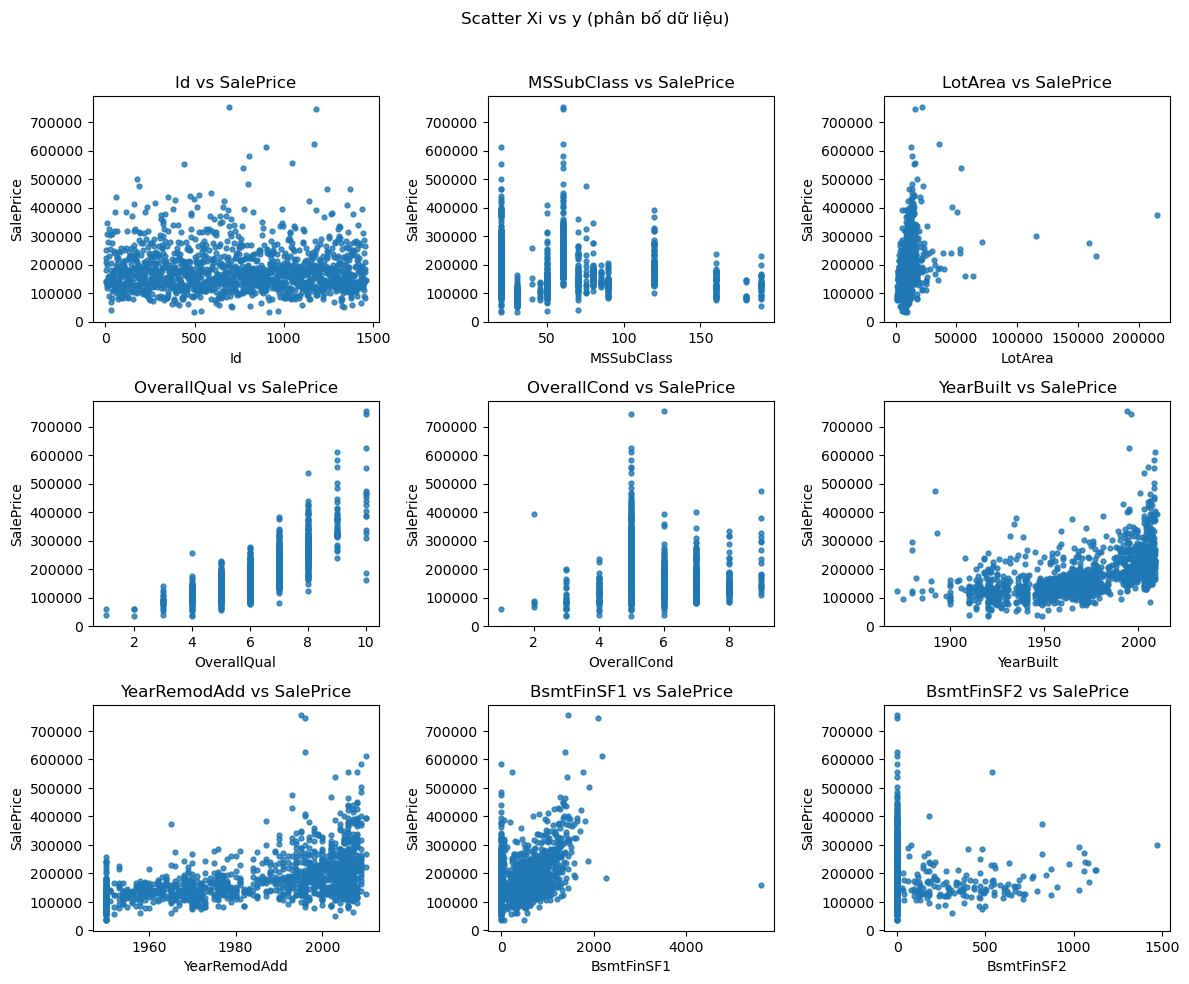

In [6]:
# Scatter dữ liệu
model.plot_data()

In [7]:
# Bảng tương quan feature vs target
model.describe_variables()


=== Nhận định biến (tương quan với y) ===
feature              |       r | chiều        | độ mạnh
-------------------------------------------------------
OverallQual          |  +0.791 | tăng (dương) | mạnh  
GrLivArea            |  +0.709 | tăng (dương) | mạnh  
GarageCars           |  +0.640 | tăng (dương) | khá   
GarageArea           |  +0.623 | tăng (dương) | khá   
TotalBsmtSF          |  +0.614 | tăng (dương) | khá   
1stFlrSF             |  +0.606 | tăng (dương) | khá   
FullBath             |  +0.561 | tăng (dương) | khá   
TotRmsAbvGrd         |  +0.534 | tăng (dương) | khá   
YearBuilt            |  +0.523 | tăng (dương) | khá   
YearRemodAdd         |  +0.507 | tăng (dương) | khá   
Fireplaces           |  +0.467 | tăng (dương) | vừa   
BsmtFinSF1           |  +0.386 | tăng (dương) | vừa   
WoodDeckSF           |  +0.324 | tăng (dương) | vừa   
2ndFlrSF             |  +0.319 | tăng (dương) | vừa   
OpenPorchSF          |  +0.316 | tăng (dương) | vừa   
HalfBath            

,feature,r,chiều,độ mạnh
0,OverallQual,0.790982,tăng (dương),mạnh
1,GrLivArea,0.708624,tăng (dương),mạnh
2,GarageCars,0.640409,tăng (dương),khá
3,GarageArea,0.623431,tăng (dương),khá
4,TotalBsmtSF,0.613581,tăng (dương),khá
5,1stFlrSF,0.605852,tăng (dương),khá
6,FullBath,0.560664,tăng (dương),khá
7,TotRmsAbvGrd,0.533723,tăng (dương),khá
8,YearBuilt,0.522897,tăng (dương),khá
9,YearRemodAdd,0.507101,tăng (dương),khá


In [ ]:
# BƯỚC MỚI: chọn feature & degree theo RAM
model.select_features_and_degree()
print("")


=== Kết quả chọn Feature & Degree theo RAM (NEW) ===
Số dòng N = 1460, Số cột M = 35, Tổng feature gốc = 34
Số feature đủ điều kiện (|r| >= 0.1): 26
Số feature mạnh (|r| >= 0.7): 2
Feature được chọn: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'Fireplaces', 'BsmtFinSF1', 'WoodDeckSF', '2ndFlrSF', 'OpenPorchSF', 'HalfBath', 'LotArea', 'BsmtFullBath', 'BsmtUnfSF', 'BedroomAbvGr', 'KitchenAbvGr', 'EnclosedPorch', 'ScreenPorch', 'PoolArea', 'MSSubClass', 'OverallCond']
Degree tối đa theo RAM: 5
Ước lượng RAM cho X_poly: ~1.85 GB



In [9]:
# Chọn degree bằng CV + huấn luyện
model.select_degree_and_train()


>>> Loại mô hình theo số biến: Đa hồi quy (n_features = 26)

=== Kết quả đánh giá các bậc đa thức ===
deg | Train RMSE | Test RMSE | Test R2 |     CV RMSE (mean±std)
---------------------------------------------------------------
  1 | 34272.9032 | 37263.3020 | 0.8190 | 36434.3191 ± 7831.8634
  2 | 17049.6121 | 42710.3621 | 0.7622 | 64645.0746 ± 17103.1268
  3 | 222.6332 | 615759.8662 | -48.4321 | 1081683.4424 ± 655972.5425
  4 | 222.6332 | 447553.4598 | -25.1142 | 1141137.1798 ± 833101.2059

Best degree (min CV RMSE): 1
1-SE rule degree (đơn giản hơn, gần tối ưu): 1
=> Degree được chọn theo chiến lược [Best CV]: 1


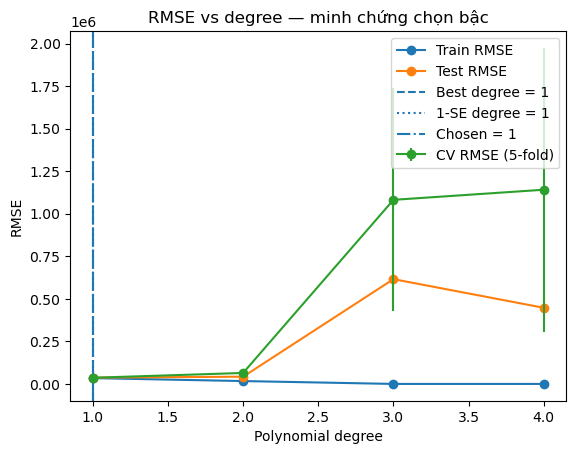

In [10]:
# Vẽ kết quả CV
model.plot_cv_results()

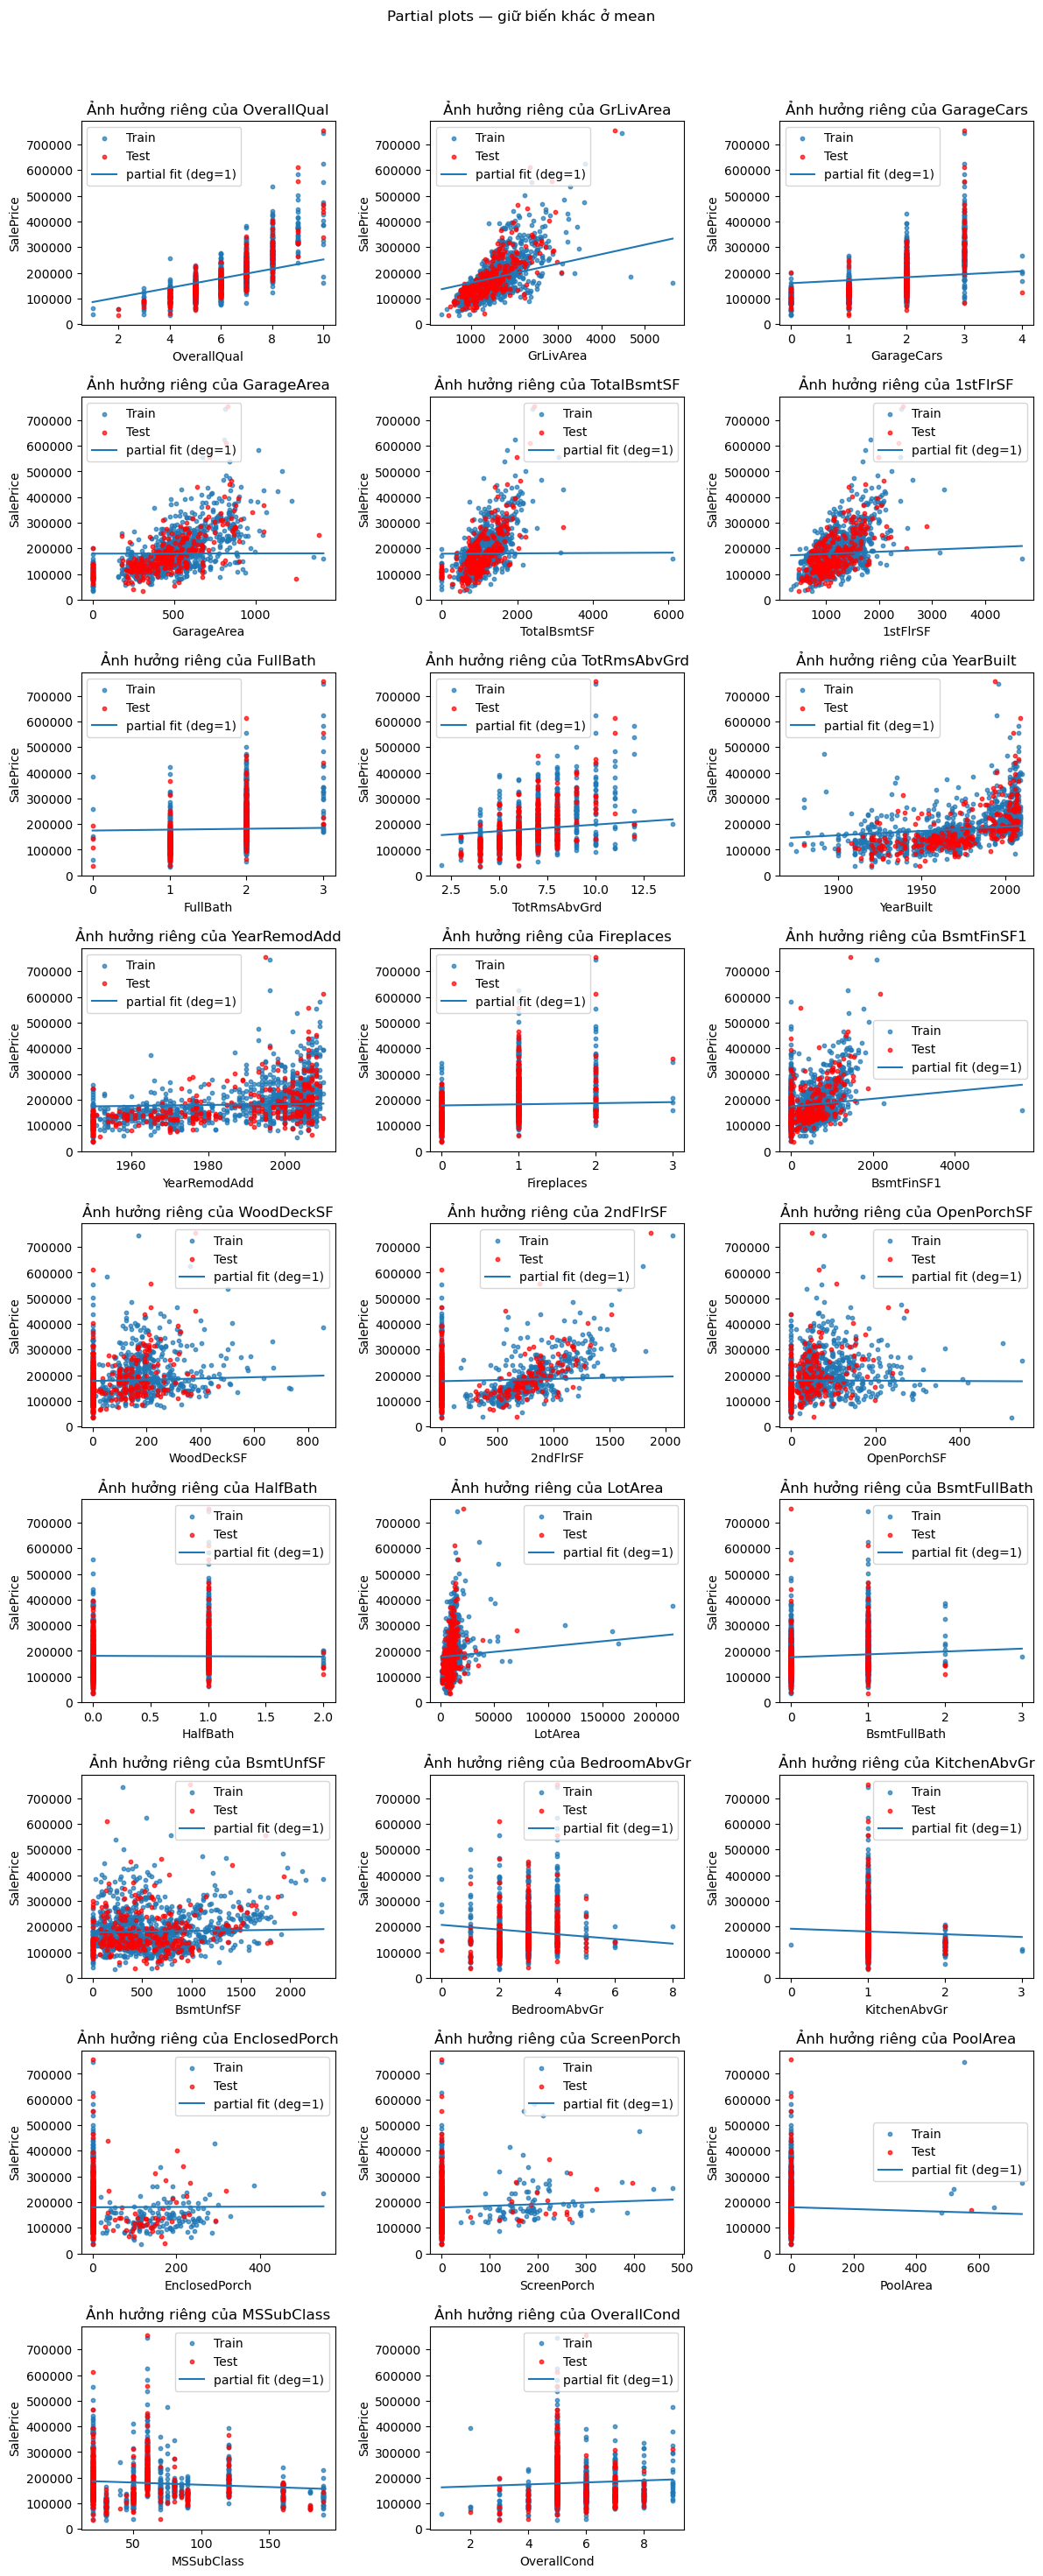

In [11]:
# Vẽ fit / partial predictions
model.plot_fit()

In [12]:
# Đánh giá mô hình
model.evaluate()


=== Đánh giá mô hình cuối (train/test) ===
   degree_chosen  n_features_raw  n_features_poly   Train_MAE  Train_RMSE  \
0              1              34               26  21037.2043  34272.9032   

   Train_R2  Train_AdjR2  Train_r    Test_MAE  Test_RMSE  Test_R2  Test_AdjR2  \
0    0.8031       0.7986   0.8961  22882.7261  37263.302    0.819      0.8012   

   Test_r  
0  0.9101  


,degree_chosen,n_features_raw,n_features_poly,Train_MAE,Train_RMSE,Train_R2,Train_AdjR2,Train_r,Test_MAE,Test_RMSE,Test_R2,Test_AdjR2,Test_r
0,1,34,26,21037.20429,34272.903237,0.803064,0.798577,0.896139,22882.726077,37263.302003,0.818971,0.801209,0.91014


In [13]:
# Nhận xét kết quả
model.interpret_results()


=== Nhận xét kết quả ===
- Mô hình giải thích tốt (0.82 R² trên test).
- Hệ số tương quan Pearson r trên test = 0.91.
- MAE (test) = 22882.73, RMSE (test) = 37263.30.
- Không có dấu hiệu overfitting rõ rệt.


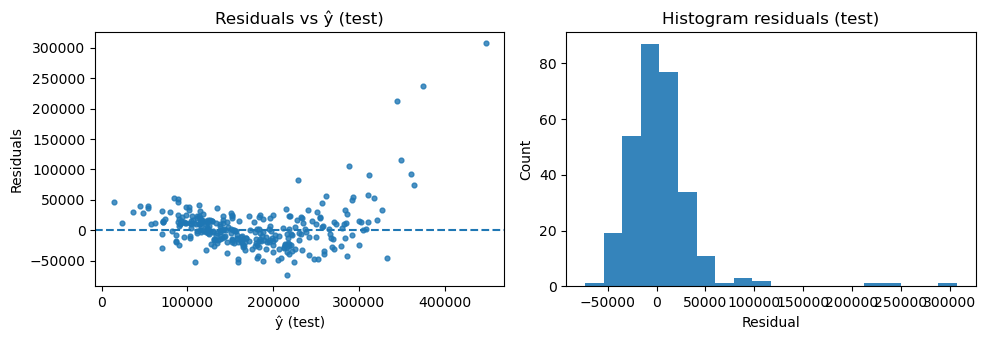

In [14]:
# Vẽ residual plots
model.plot_residuals()

4. Hoặc chạy trọn gói

In [15]:

# model.run_full_pipeline()